# DINO Clustering Evaluation

This notebook evaluates the clustering results of DINO features reduced by PCA, projected with UMAP, and clustered with HDBSCAN.
We analyze cluster sizes, compactness, separation, internal clustering metrics, and generate final visualizations.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import euclidean_distances

# Setup plot styles
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 18
})

# Paths
embeddings_dir = "../embeddings"
notebooks_dir = "."
outputs_dir = "../outputs"
os.makedirs(outputs_dir, exist_ok=True)

# Load data
dino_features = np.load(os.path.join(embeddings_dir, "dino_features.npy"))
pca_features = np.load(os.path.join(notebooks_dir, "pca_features.npy"))
umap_embeddings = np.load(os.path.join(notebooks_dir, "umap_dino_embeddings.npy"))
clusters = np.load(os.path.join(notebooks_dir, "dino_clusters.npy"))
image_paths = np.load(os.path.join(notebooks_dir, "image_paths.npy"))

# Verify lengths
n_samples = len(image_paths)
assert len(dino_features) == n_samples
assert len(pca_features) == n_samples
assert len(umap_embeddings) == n_samples
assert len(clusters) == n_samples

print(f"Loaded {n_samples:,} images successfully.")
print(f"DINO features shape: {dino_features.shape}")
print(f"PCA features shape: {pca_features.shape}")
print(f"UMAP embeddings shape: {umap_embeddings.shape}")
print(f"Clusters shape: {clusters.shape}")

Loaded 51,301 images successfully.
DINO features shape: (51301, 384)
PCA features shape: (51301, 200)
UMAP embeddings shape: (51301, 2)
Clusters shape: (51301,)


## 2. Dataset Statistics

We generate summary statistics of our clustering results including noise points.

In [2]:
unique_clusters = [c for c in np.unique(clusters) if c != -1]
num_clusters = len(unique_clusters)
num_noise = np.sum(clusters == -1)
pct_noise = (num_noise / n_samples) * 100

cluster_sizes = [np.sum(clusters == c) for c in unique_clusters]
max_size = np.max(cluster_sizes)
min_size = np.min(cluster_sizes)
mean_size = np.mean(cluster_sizes)
median_size = np.median(cluster_sizes)

stats_df = pd.DataFrame({
    "Metric": [
        "Total images",
        "Total clusters (excluding noise)",
        "Number of noise points",
        "Noise percentage",
        "Largest cluster size",
        "Smallest cluster size",
        "Mean cluster size",
        "Median cluster size"
    ],
    "Value": [
        n_samples,
        num_clusters,
        num_noise,
        f"{pct_noise:.2f}%",
        max_size,
        min_size,
        f"{mean_size:.2f}",
        median_size
    ]
})

display(stats_df)
stats_df.to_csv(os.path.join(outputs_dir, "cluster_statistics.csv"), index=False)

,Metric,Value
0,Total images,51301
1,Total clusters (excluding noise),12
2,Number of noise points,6986
3,Noise percentage,13.62%
4,Largest cluster size,26397
5,Smallest cluster size,373
6,Mean cluster size,3692.92
7,Median cluster size,737.5


## 3. Cluster Size Analysis

We visualize the distribution of cluster sizes with and without the noise cluster.

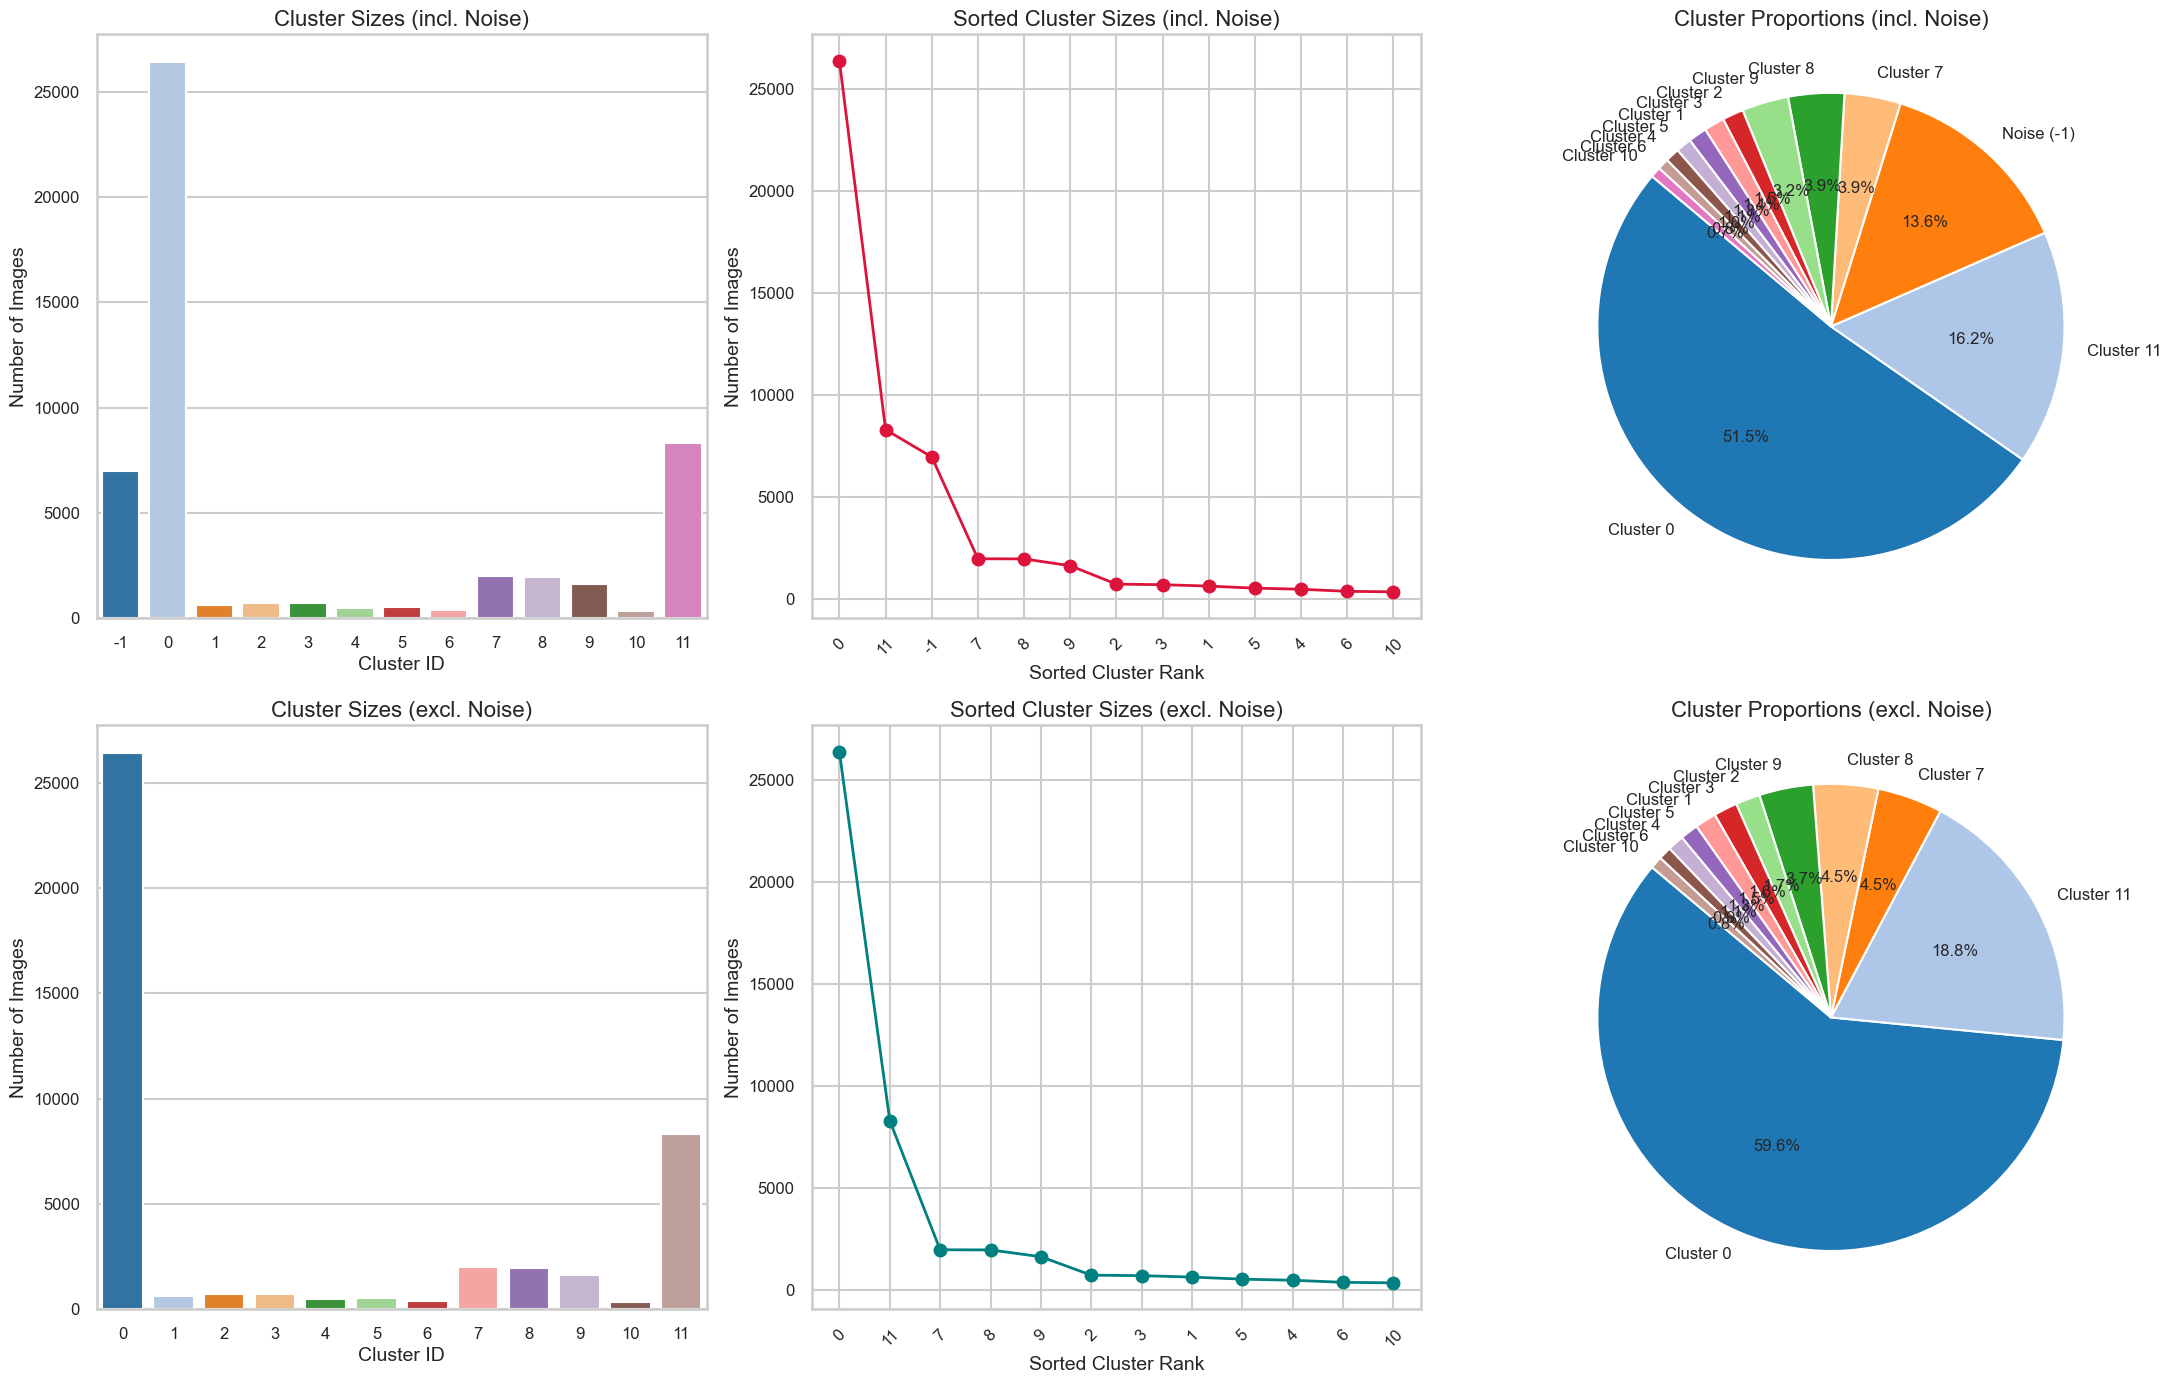

In [3]:
all_labels, counts = np.unique(clusters, return_counts=True)

# 1. Including noise
df_with_noise = pd.DataFrame({'Cluster': all_labels, 'Size': counts}).sort_values('Size', ascending=False)
df_with_noise['Label'] = df_with_noise['Cluster'].apply(lambda x: f"Cluster {x}" if x != -1 else "Noise (-1)")

# 2. Excluding noise
mask_no_noise = all_labels != -1
df_no_noise = pd.DataFrame({'Cluster': all_labels[mask_no_noise], 'Size': counts[mask_no_noise]}).sort_values('Size', ascending=False)
df_no_noise['Label'] = df_no_noise['Cluster'].apply(lambda x: f"Cluster {x}")

fig, axes = plt.subplots(2, 3, figsize=(22, 14))

# Row 0: With Noise
# Bar chart
sns.barplot(data=df_with_noise, x='Cluster', y='Size', ax=axes[0, 0], hue='Cluster', palette='tab20', legend=False)
axes[0, 0].set_title("Cluster Sizes (incl. Noise)")
axes[0, 0].set_xlabel("Cluster ID")
axes[0, 0].set_ylabel("Number of Images")

# Sorted plot
axes[0, 1].plot(range(len(df_with_noise)), df_with_noise['Size'], marker='o', color='crimson', linewidth=2)
axes[0, 1].set_title("Sorted Cluster Sizes (incl. Noise)")
axes[0, 1].set_xticks(range(len(df_with_noise)))
axes[0, 1].set_xticklabels(df_with_noise['Cluster'], rotation=45)
axes[0, 1].set_xlabel("Sorted Cluster Rank")
axes[0, 1].set_ylabel("Number of Images")

# Pie chart
axes[0, 2].pie(df_with_noise['Size'], labels=df_with_noise['Label'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('tab20', len(df_with_noise)))
axes[0, 2].set_title("Cluster Proportions (incl. Noise)")

# Row 1: Without Noise
# Bar chart
sns.barplot(data=df_no_noise, x='Cluster', y='Size', ax=axes[1, 0], hue='Cluster', palette='tab20', legend=False)
axes[1, 0].set_title("Cluster Sizes (excl. Noise)")
axes[1, 0].set_xlabel("Cluster ID")
axes[1, 0].set_ylabel("Number of Images")

# Sorted plot
axes[1, 1].plot(range(len(df_no_noise)), df_no_noise['Size'], marker='o', color='teal', linewidth=2)
axes[1, 1].set_title("Sorted Cluster Sizes (excl. Noise)")
axes[1, 1].set_xticks(range(len(df_no_noise)))
axes[1, 1].set_xticklabels(df_no_noise['Cluster'], rotation=45)
axes[1, 1].set_xlabel("Sorted Cluster Rank")
axes[1, 1].set_ylabel("Number of Images")

# Pie chart
axes[1, 2].pie(df_no_noise['Size'], labels=df_no_noise['Label'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('tab20', len(df_no_noise)))
axes[1, 2].set_title("Cluster Proportions (excl. Noise)")

plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, "cluster_size_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

## 4. Internal Clustering Metrics

We calculate Silhouette, Davies-Bouldin, and Calinski-Harabasz metrics on the PCA features (excluding noise).

In [4]:
mask_valid = clusters != -1
X_valid = pca_features[mask_valid]
labels_valid = clusters[mask_valid]

print("Calculating Silhouette Score (this may take 1-2 minutes)...")
sil = silhouette_score(X_valid, labels_valid)
print("Calculating Davies-Bouldin Index...")
db = davies_bouldin_score(X_valid, labels_valid)
print("Calculating Calinski-Harabasz Index...")
ch = calinski_harabasz_score(X_valid, labels_valid)

metrics_df = pd.DataFrame({
    "Metric": ["Silhouette Score", "Davies-Bouldin Index", "Calinski-Harabasz Index"],
    "Value": [sil, db, ch]
})

display(metrics_df)
stats_df_loaded = pd.read_csv(os.path.join(outputs_dir, "cluster_statistics.csv"))
combined_stats_df = pd.concat([stats_df_loaded, metrics_df], ignore_index=True)
combined_stats_df.to_csv(os.path.join(outputs_dir, "cluster_statistics.csv"), index=False)

Calculating Silhouette Score (this may take 1-2 minutes)...


Calculating Davies-Bouldin Index...
Calculating Calinski-Harabasz Index...


,Metric,Value
0,Silhouette Score,0.124340
1,Davies-Bouldin Index,2.846587
2,Calinski-Harabasz Index,1433.320096


## 5. Cluster Compactness Analysis

We measure the compactness of each cluster by looking at the distances from the points in each cluster to their centroid.

In [5]:
compactness_data = []

for c in unique_clusters:
    idx = np.where(clusters == c)[0]
    c_features = pca_features[idx]
    
    # Centroid
    centroid = np.mean(c_features, axis=0)
    
    # Distance of each sample to the centroid
    distances = np.linalg.norm(c_features - centroid, axis=1)
    
    compactness_data.append({
        "Cluster ID": c,
        "Size": len(idx),
        "Compactness (Mean Distance)": np.mean(distances),
        "Std Distance": np.std(distances),
        "Max Distance": np.max(distances)
    })

compactness_df = pd.DataFrame(compactness_data)
compactness_df = compactness_df.sort_values("Compactness (Mean Distance)").reset_index(drop=True)

print("Cluster Compactness Ranking (lower mean distance means more compact):")
display(compactness_df)

most_compact = compactness_df.iloc[0]
most_dispersed = compactness_df.iloc[-1]

print(f"\nMost Compact Cluster: Cluster {int(most_compact['Cluster ID'])} (Mean Distance to Centroid: {most_compact['Compactness (Mean Distance)']:.4f})")
print(f"Most Dispersed Cluster: Cluster {int(most_dispersed['Cluster ID'])} (Mean Distance to Centroid: {most_dispersed['Compactness (Mean Distance)']:.4f})")

Cluster Compactness Ranking (lower mean distance means more compact):

,Cluster ID,Size,Compactness (Mean Distance),Std Distance,Max Distance
0,1,656,27.901308,5.042221,42.854618
1,10,373,28.015385,4.082895,41.349472
2,9,1654,28.467211,4.316768,41.732517
3,0,26397,28.701441,7.847433,60.273098
4,2,750,28.862667,4.216727,50.169380
5,6,399,29.919689,4.340501,43.727833
6,8,1988,32.493031,3.514949,44.984024
7,7,1995,34.027760,4.729162,48.708622
8,4,501,34.688190,4.112840,46.065845
9,11,8323,34.856499,3.536918,49.240242



Most Compact Cluster: Cluster 1 (Mean Distance to Centroid: 27.9013)
Most Dispersed Cluster: Cluster 3 (Mean Distance to Centroid: 38.7581)


## 6. Cluster Separation Analysis

We analyze how well-separated our clusters are by computing the Euclidean distance between cluster centroids.

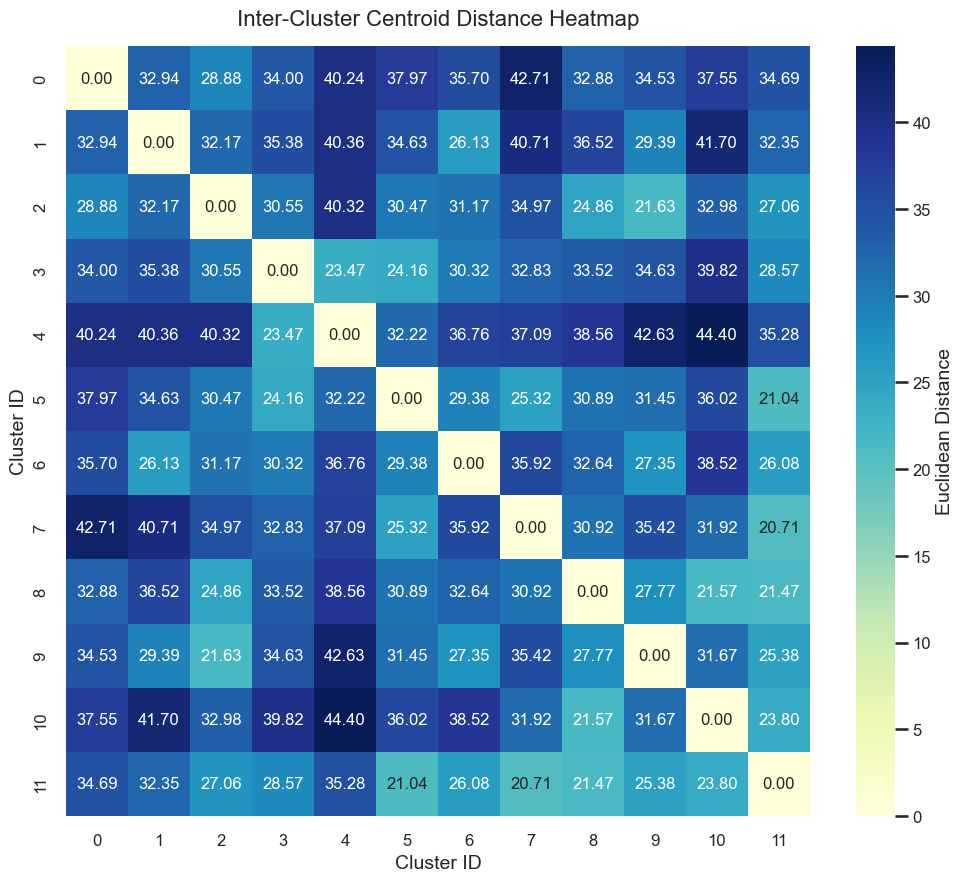

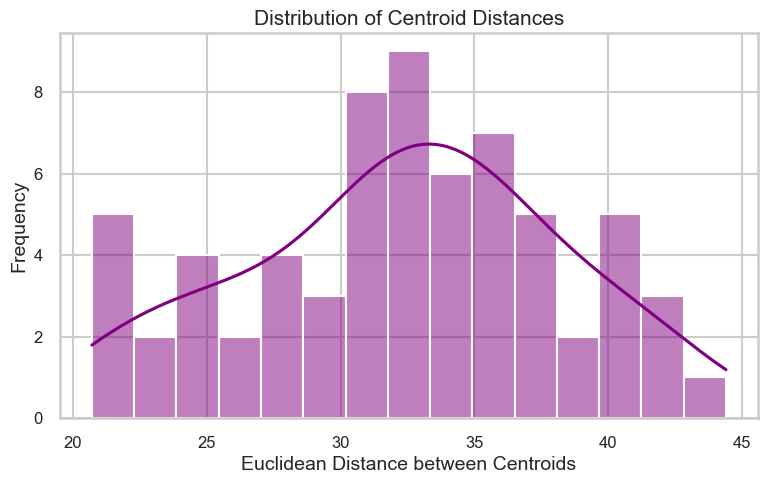

Nearest Cluster Pairs (closest first):


,Cluster 1,Cluster 2,Distance
0,7,11,20.710819
1,5,11,21.037682
2,8,11,21.466595
3,8,10,21.571243
4,2,9,21.629318
5,3,4,23.474669
6,10,11,23.802330
7,3,5,24.155174
8,2,8,24.863691
9,5,7,25.323889


In [6]:
centroids = {}
for c in unique_clusters:
    idx = np.where(clusters == c)[0]
    centroids[c] = np.mean(pca_features[idx], axis=0)

ordered_centroids = np.array([centroids[c] for c in sorted(unique_clusters)])
cluster_ids_sorted = sorted(unique_clusters)

dist_matrix = euclidean_distances(ordered_centroids)
dist_matrix_df = pd.DataFrame(dist_matrix, index=cluster_ids_sorted, columns=cluster_ids_sorted)

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(dist_matrix_df, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Euclidean Distance'})
plt.title("Inter-Cluster Centroid Distance Heatmap", fontsize=16, pad=15)
plt.xlabel("Cluster ID")
plt.ylabel("Cluster ID")
plt.savefig(os.path.join(outputs_dir, "cluster_centroid_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

# Save distance matrix
dist_matrix_df.to_csv(os.path.join(outputs_dir, "cluster_distance_matrix.csv"))

# Histogram of centroid distances
triu_indices = np.triu_indices_from(dist_matrix, k=1)
flat_distances = dist_matrix[triu_indices]

plt.figure(figsize=(9, 5))
sns.histplot(flat_distances, bins=15, kde=True, color='purple')
plt.title("Distribution of Centroid Distances", fontsize=15)
plt.xlabel("Euclidean Distance between Centroids")
plt.ylabel("Frequency")
plt.show()

# Nearest cluster pairs
nearest_pairs = []
for i, c1 in enumerate(cluster_ids_sorted):
    for j, c2 in enumerate(cluster_ids_sorted):
        if i < j:
            nearest_pairs.append({
                "Cluster 1": c1,
                "Cluster 2": c2,
                "Distance": dist_matrix[i, j]
            })

nearest_pairs_df = pd.DataFrame(nearest_pairs).sort_values("Distance").reset_index(drop=True)
print("Nearest Cluster Pairs (closest first):")
display(nearest_pairs_df.head(10))

## 7. UMAP Visualization

We generate a high-quality, publication-ready scatter plot of the UMAP embeddings colored by cluster membership with noise highlighted in gray.

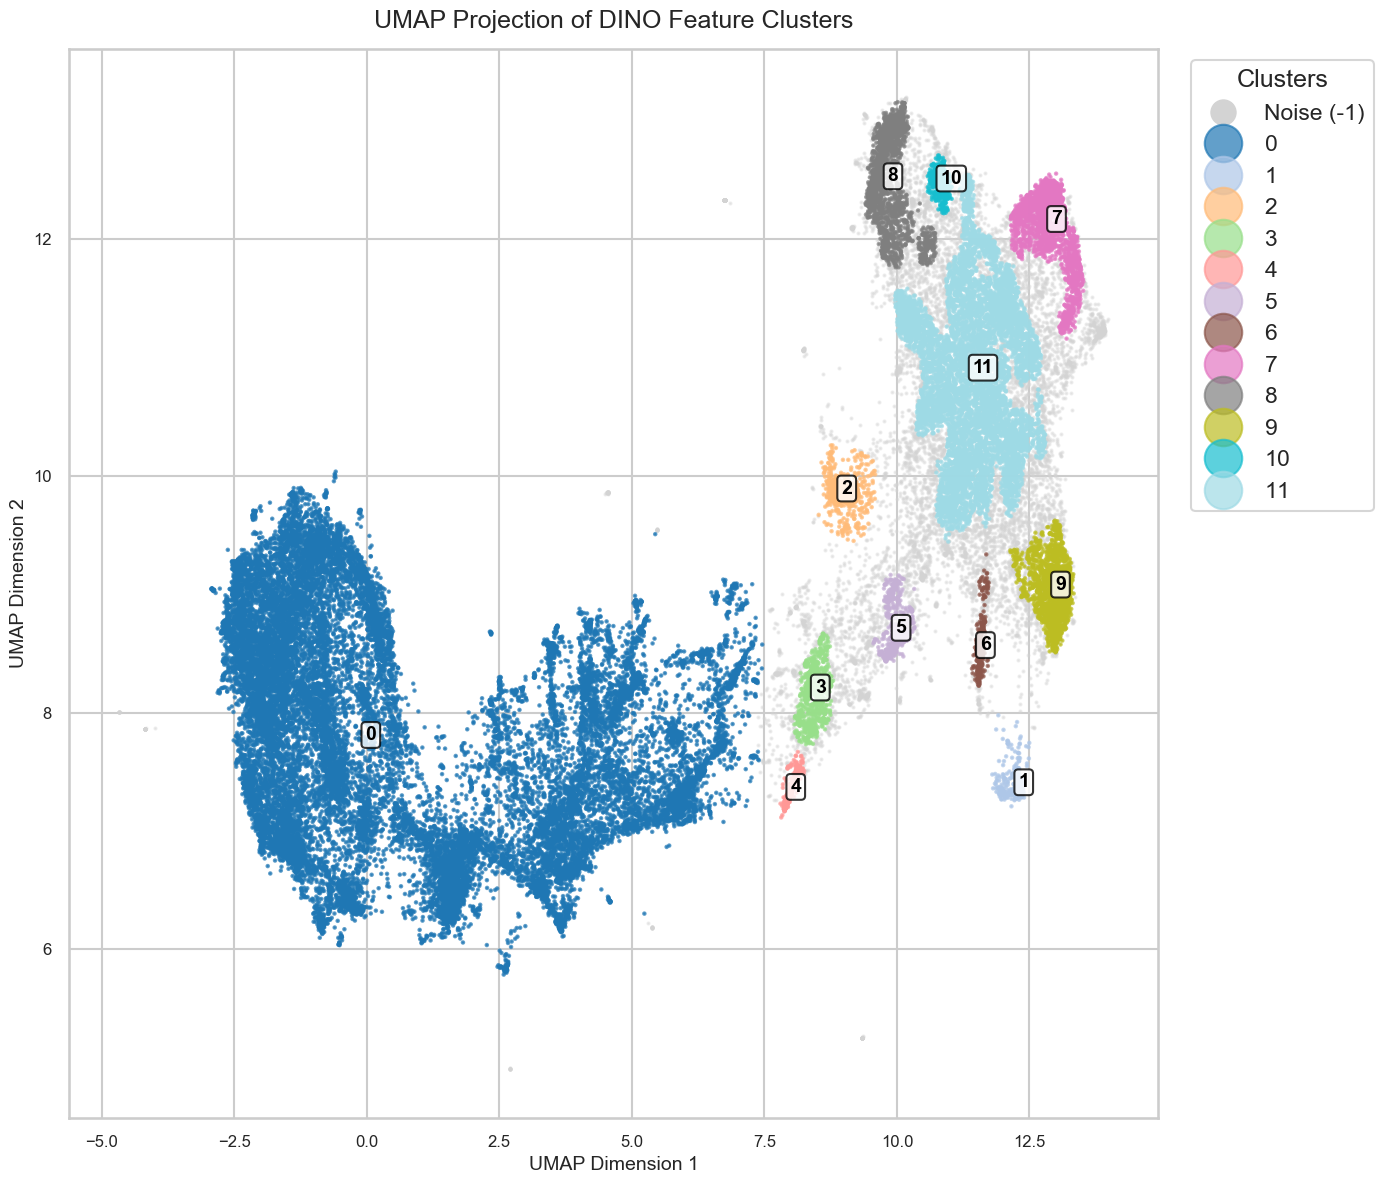

In [7]:
plt.figure(figsize=(14, 12))

# Noise points
noise_mask = clusters == -1
plt.scatter(
    umap_embeddings[noise_mask, 0],
    umap_embeddings[noise_mask, 1],
    c='lightgray',
    s=2,
    alpha=0.4,
    label='Noise (-1)'
)

# Non-noise clusters
non_noise_mask = ~noise_mask
scatter = plt.scatter(
    umap_embeddings[non_noise_mask, 0],
    umap_embeddings[non_noise_mask, 1],
    c=clusters[non_noise_mask],
    cmap='tab20',
    s=3,
    alpha=0.7
)

# Annotate cluster labels on the centers
for c in unique_clusters:
    idx = np.where(clusters == c)[0]
    center_umap = np.median(umap_embeddings[idx], axis=0)
    plt.text(
        center_umap[0],
        center_umap[1],
        str(c),
        fontsize=14,
        fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2', alpha=0.8)
    )

plt.title("UMAP Projection of DINO Feature Clusters", fontsize=18, pad=15)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

# Detailed Legend
handles, labels_legend = scatter.legend_elements(prop="colors")
import matplotlib.lines as mlines
noise_handle = mlines.Line2D([], [], color='lightgray', marker='o', linestyle='None', markersize=6, label='Noise (-1)')
handles.insert(0, noise_handle)
labels_legend.insert(0, 'Noise (-1)')

plt.legend(handles, labels_legend, title="Clusters", bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=3)
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, "dino_umap_clusters.png"), dpi=300, bbox_inches='tight')
plt.show()

## 8. Cluster Quality Report

We compile a comprehensive quality report dataframe containing: Cluster ID, Size, Compactness (mean intra-cluster distance), Mean distance to other centroids, and Distance to nearest cluster (nearest neighbor centroid distance).

In [8]:
quality_report = []

for i, c in enumerate(cluster_ids_sorted):
    compactness = compactness_df[compactness_df["Cluster ID"] == c]["Compactness (Mean Distance)"].values[0]
    size = compactness_df[compactness_df["Cluster ID"] == c]["Size"].values[0]
    
    row_distances = dist_matrix[i]
    mean_dist_other = np.mean(row_distances[row_distances > 0])
    dist_nearest = np.min(row_distances[row_distances > 0])
    
    quality_report.append({
        "Cluster ID": c,
        "Size": int(size),
        "Compactness": compactness,
        "Mean intra-cluster distance": compactness, # As requested
        "Distance to nearest cluster": dist_nearest
    })

quality_report_df = pd.DataFrame(quality_report)
quality_report_df = quality_report_df.sort_values("Compactness").reset_index(drop=True)

print("Final Cluster Quality Report (Sorted by Compactness):")
display(quality_report_df)

quality_report_df.to_csv(os.path.join(outputs_dir, "cluster_quality_report.csv"), index=False)

Final Cluster Quality Report (Sorted by Compactness):


,Cluster ID,Size,Compactness,Mean intra-cluster distance,Distance to nearest cluster
0,1,656,27.901308,27.901308,26.130480
1,10,373,28.015385,28.015385,21.571243
2,9,1654,28.467211,28.467211,21.629318
3,0,26397,28.701441,28.701441,28.883852
4,2,750,28.862667,28.862667,21.629318
5,6,399,29.919689,29.919689,26.081234
6,8,1988,32.493031,32.493031,21.466595
7,7,1995,34.027760,34.027760,20.710819
8,4,501,34.688190,34.688190,23.474669
9,11,8323,34.856499,34.856499,20.710819
